In [18]:
from __future__ import annotations

from typing import TypeAlias, Any
import numpy as np
from numpy.typing import NDArray

from train import AbPNLTrainer
from synthproblems import PostNonlinearNToOne, generate_samples


In [19]:
T: TypeAlias = NDArray[np.floating[Any]]


def d_edit(a: T, b: T) -> Any:
    return np.logical_xor((a != 0), (b != 0)).sum()


def n_rev(a: T, b: T) -> Any:
    return ((a != 0) * (b != 0).T).sum()



In [20]:
import pandas as pd
import graphviz
import lingam
from lingam.utils import make_dot

print([np.__version__, pd.__version__, graphviz.__version__, lingam.__version__])

np.set_printoptions(precision=3, suppress=True)
np.random.seed(100)

size = 10000
np.random.seed(123)
w = np.random.uniform(size=size, low=-3.0, high=3.0)
nx = np.random.uniform(size=size, low=-1.0, high=1.0)
ny = np.random.uniform(size=size, low=-1.0, high=1.0)
nz = np.random.uniform(size=size, low=-1.0, high=1.0)

x=w*w + nx
y=4*np.sqrt(np.abs(w))+ny
z = 2*np.sin(x)+2*np.sin(y) + nz

xs = np.array([w,x,y,z]).T
X = pd.DataFrame(np.array([w,x,y,z]).T,columns=["w", "x", "y", "z"])
X.head()

['1.26.4', '2.2.3', '0.20.3', '1.9.1']


,w,x,y,z
0,1.178815,1.715890,3.515885,2.035787
1,-1.283164,2.326083,4.699402,-0.567909
2,-1.638891,3.333273,5.066271,-2.342848
3,0.307889,-0.169981,2.624754,0.943185
4,1.316814,1.085181,4.513312,-0.758273


In [21]:
X=X.astype(np.float32)
k = int(0.7*size)
x_train = X[:k].values
x_test = X[k:].values

x_train


array([[ 1.179,  1.716,  3.516,  2.036],
       [-1.283,  2.326,  4.699, -0.568],
       [-1.639,  3.333,  5.066, -2.343],
       ...,
       [ 2.05 ,  4.17 ,  6.387, -1.629],
       [-1.335,  2.7  ,  3.702, -0.068],
       [ 1.214,  2.162,  4.102,  0.711]], dtype=float32)

In [22]:
params = AbPNLTrainer.default_params
params["logdir"] = "results/eg1"
params["max_workers"] = 3
#params["n_units"] = 16
#params["batchsize"] = 64

abpnl = AbPNLTrainer(params)

In [23]:
abpnl.doit(x_train, x_test)

co = abpnl.causal_order
am = abpnl.adjacency_matrix

causal order: [2]
causal order: [2, 3]
causal order: [2, 3, 1]


In [24]:
am

array([[0, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 1, 0, 1],
       [1, 1, 0, 0]])

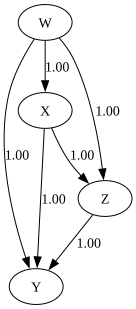

In [25]:


dot = make_dot(am, labels=['W', 'X','Y','Z'])
# Save pdf
dot.render('dag')

# Save png
dot.format = 'png'
dot.render('dag')

dot
